# Acero

In [1]:
import pandas as pd 
import numpy as np 
import scipy as sp 
import matplotlib.pyplot as plt 

In [2]:
def get_last_second_amplitude(t, V):
    t = np.asarray(t)
    V = np.asarray(V)
        
    t_end = t[-1]
    t_start = t_end - 1.0
    
    mask = t >= t_start
    
    V_last_second = V[mask]
    
    if len(V_last_second) == 0:
        return 0.0
        
    amplitude = (np.max(V_last_second) - np.min(V_last_second)) / 2.0
    
    return amplitude

In [3]:
import glob

amplitudes = []
frequencies = []

# Loop through all csv files in the folder
for file_path in glob.glob('data_clean_cuarta_clase/acero/*.csv'):
    
    # 1. Extract the frequency from the first line like before
    with open(file_path, 'r', encoding='utf-8') as file:
        first_line = file.readline()
        freq = float(first_line.split('frecuencia:')[1].strip())
        frequencies.append(freq)
        
    # 2. Read the actual data using pandas
    # skiprows=2 ignores the first two metadata lines so it uses "Time (s),Voltage (V)" as headers
    df = pd.read_csv(file_path, skiprows=2)
    
    # Extract the columns into variables t and V
    t = df['Time (s)'].values
    V = df['Voltage (V)'].values
    
    # 3. Apply your function
    amp = get_last_second_amplitude(t, V)
    
    # 4. Save the amplitude to our array
    amplitudes.append(amp)

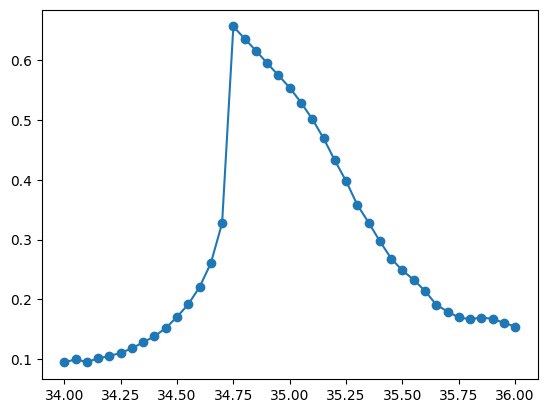

In [4]:
plt.plot(frequencies, amplitudes, marker='o') 

In [5]:
f_data = np.array(frequencies)
a_data = np.array(amplitudes)

<>:112: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:112: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
C:\Users\nysg\AppData\Local\Temp\ipykernel_19048\1809744627.py:112: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.xlabel('Driving Frequency $\omega$')


w0 = 35.174, alpha = -120.62, zeta = 3.79e-08, F = 7.660


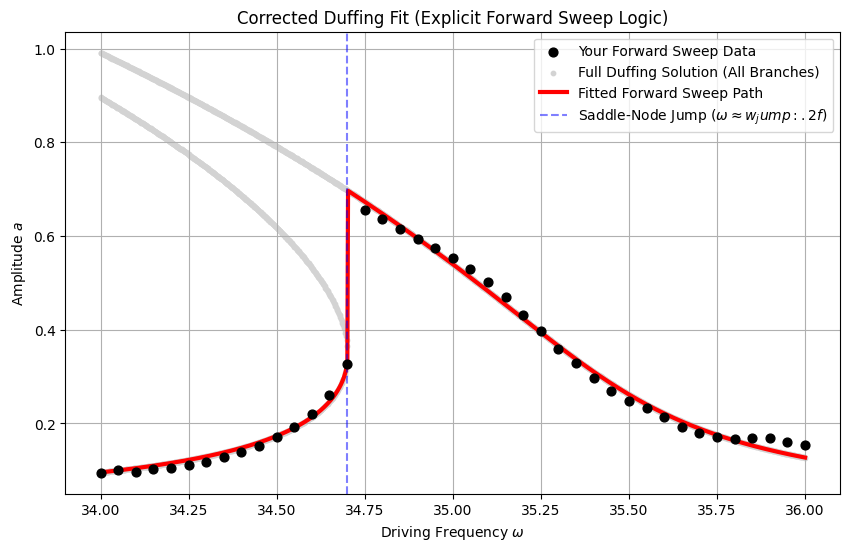

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Your provided data
w_data = np.array([34., 34.05, 34.1, 34.15, 34.2, 34.25, 34.3, 34.35, 34.4, 34.45, 
                   34.5, 34.55, 34.6, 34.65, 34.7, 34.75, 34.8, 34.85, 34.9, 34.95, 
                   35., 35.05, 35.1, 35.15, 35.2, 35.25, 35.3, 35.35, 35.4, 35.45, 
                   35.5, 35.55, 35.6, 35.65, 35.7, 35.75, 35.8, 35.85, 35.9, 35.95, 36.])

a_data = np.array([0.0947, 0.1001, 0.0956, 0.1016, 0.1055, 0.1107, 0.1183, 0.1285, 0.1384, 0.1521, 
                   0.1709, 0.1918, 0.2207, 0.2605, 0.3273, 0.6559, 0.6356, 0.6155, 0.5946, 0.5742, 
                   0.5536, 0.5289, 0.5013, 0.4693, 0.4322, 0.3977, 0.3578, 0.3284, 0.2972, 0.2684, 
                   0.2484, 0.2330, 0.2142, 0.1913, 0.1798, 0.1699, 0.1670, 0.1697, 0.1678, 0.1609, 0.1547])

def simulate_forward_sweep(w_array, w0, alpha, zeta, F):
    """
    Solves the exact Duffing cubic at each step, dropping unstable roots 
    and enforcing the continuity of a physical forward sweep.
    """
    a_sim = np.zeros(len(w_array))
    current_a = 0.0
    
    for i, w in enumerate(w_array):
        # Coefficients for the cubic in terms of x = a^2
        C3 = (9/16) * alpha**2
        C2 = (3/2) * alpha * (w0**2 - w**2)
        C1 = (w0**2 - w**2)**2 + 4 * zeta**2 * w0**2 * w**2
        C0 = -F**2
        
        # Find roots of the cubic
        roots = np.roots([C3, C2, C1, C0])
        
        # Filter for real, positive roots (amplitude must be real/positive)
        real_roots = np.real(roots[np.isclose(np.imag(roots), 0, atol=1e-8)])
        pos_roots = np.sort(real_roots[real_roots > 0])
        
        if len(pos_roots) == 0:
            a_sim[i] = current_a
            continue
            
        pos_a = np.sqrt(pos_roots)
        
        # Continuity logic for a Forward Sweep
        if i == 0:
            current_a = pos_a[0] # Start on the lowest stable branch
        else:
            if len(pos_a) == 1:
                current_a = pos_a[0]
            elif len(pos_a) == 3:
                a_low, a_mid, a_high = pos_a
                # a_mid is mathematically unstable. 
                # Pick lower or upper based on where we are.
                if current_a < a_mid:
                    current_a = a_low
                else:
                    current_a = a_high
            else:
                # Exactly at bifurcation boundary
                idx = np.argmin(np.abs(pos_a - current_a))
                current_a = pos_a[idx]
                
        a_sim[i] = current_a
        
    return a_sim

# Cost function for the optimizer
def cost_fn(params):
    w0, alpha, zeta, F = params
    if zeta < 0 or F < 0: # Physical bounds
        return 1e6
    a_sim = simulate_forward_sweep(w_data, w0, alpha, zeta, F)
    return np.sum((a_sim - a_data)**2)

# Initial guess (from our earlier implicit fit)
p0 = [35.18, -96.6, 0.00466, 7.9]

# Nelder-Mead avoids gradient issues around the discontinuous jump
res = minimize(cost_fn, p0, method='Nelder-Mead')
w0_opt, alpha_opt, zeta_opt, F_opt = res.x

print(f"w0 = {w0_opt:.3f}, alpha = {alpha_opt:.2f}, zeta = {zeta_opt:.2e}, F = {F_opt:.3f}")

# ----- PLOTTING -----
w_high_res = np.linspace(34.0, 36.0, 1000)
a_high_res = simulate_forward_sweep(w_high_res, w0_opt, alpha_opt, zeta_opt, F_opt)

# Calculate ALL mathematical roots just for the background visual
w_roots, a_roots = [], []
for w in w_high_res:
    C3 = (9/16)*alpha_opt**2
    C2 = (3/2)*alpha_opt*(w0_opt**2 - w**2)
    C1 = (w0_opt**2 - w**2)**2 + 4*zeta_opt**2 * w0_opt**2 * w**2
    C0 = -F_opt**2
    roots = np.roots([C3, C2, C1, C0])
    r_real = np.real(roots[np.isclose(np.imag(roots), 0, atol=1e-8)])
    for r in np.sort(r_real[r_real > 0]):
        w_roots.append(w)
        a_roots.append(np.sqrt(r))

plt.figure(figsize=(10, 6))
plt.scatter(w_data, a_data, color='black', s=40, label='Your Forward Sweep Data', zorder=3)
plt.scatter(w_roots, a_roots, color='#d3d3d3', s=10, label='Full Duffing Solution (All Branches)', zorder=1)
plt.plot(w_high_res, a_high_res, 'r-', lw=3, label='Fitted Forward Sweep Path', zorder=2)

# Identify and plot the jump line
jump_indices = np.where(np.diff(a_high_res) > 0.1)[0]
if len(jump_indices) > 0:
    w_jump = w_high_res[jump_indices[0]]
    plt.axvline(w_jump, color='blue', linestyle='--', alpha=0.5, label=r'Saddle-Node Jump ($\omega \approx {w_jump:.2f}$)')

plt.xlabel('Driving Frequency $\omega$')
plt.ylabel('Amplitude $a$')
plt.title('Corrected Duffing Fit (Explicit Forward Sweep Logic)')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
data = np.loadtxt('data_clean_cuarta_clase/acero/measurement_20260625_131512.csv', delimiter=',',skiprows=3)
data2 = np.loadtxt('data_clean_cuarta_clase/acero/measurement_20260625_130601.csv', delimiter=',',skiprows=3)

(0.0, 2.0)

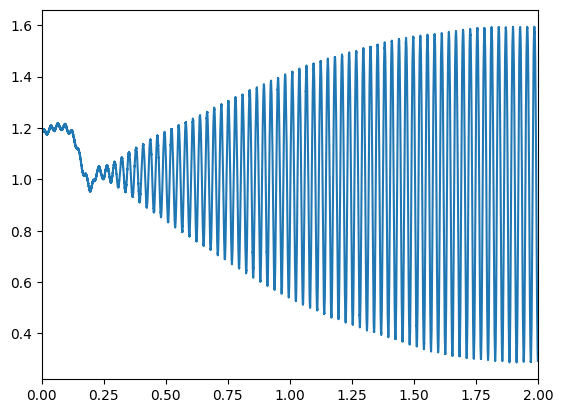

In [8]:
plt.plot(data[:,0], data[:,1])
plt.xlim(0,2)

Data points available for fit (M): 1180373
Calculated Time Constant (tau): 0.1089
Settling time (approx 5*tau): 0.5443


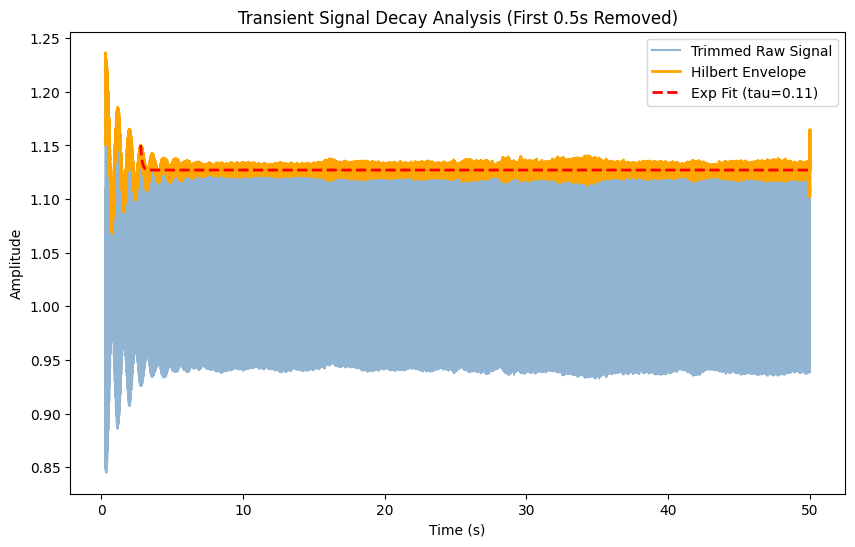

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.optimize import curve_fit

# Assuming 't' and 'y' are your raw numpy arrays from the dataset
t = data2[:, 0]
y = data2[:, 1]

# --- NEW STEP: Trim the first 0.5s ---
trim_mask = t >= 0.3
t_clean = t[trim_mask]
y_clean = y[trim_mask]

# 1. Remove DC Offset (Crucial before Hilbert transform)
y_centered = y_clean - np.mean(y_clean)

# 2. Extract the envelope using the Hilbert Transform
analytic_signal = hilbert(y_centered)
envelope = np.abs(analytic_signal)
# 3. Isolate the decay phase (Safely)
# The Hilbert transform creates false spikes at the boundaries. 
# We define a margin (e.g., 5% of the data length) to ignore these edges.
margin = int(len(envelope) * 0.05)

# Find the peak ONLY within the safe middle region
# Add the margin back to get the correct index relative to the full array
peak_idx = np.argmax(envelope[margin:-margin]) + margin

t_decay = t_clean[peak_idx:]
envelope_decay = envelope[peak_idx:]

# Quick debug print to ensure you have enough data points
print(f"Data points available for fit (M): {len(t_decay)}")

# 4. Define the exponential decay function
def exp_decay(t, A, tau, C):
    t0 = t_decay[0] # Shift time to start at 0 for the fit
    return A * np.exp(-(t - t0) / tau) + C

# 5. Perform the curve fit
# Initial guesses: [Amplitude, tau, Offset]
initial_guess = [np.max(envelope_decay) - np.min(envelope_decay), 1.0, np.min(envelope_decay)]

popt, pcov = curve_fit(exp_decay, t_decay, envelope_decay, p0=initial_guess)
A_fit, tau_fit, C_fit = popt

print(f"Calculated Time Constant (tau): {tau_fit:.4f}")
print(f"Settling time (approx 5*tau): {5 * tau_fit:.4f}")

# 6. Visualize the results
plt.figure(figsize=(10, 6))
# Plot the cleaned raw data (adding mean back for visualization if desired)
plt.plot(t_clean, y_clean, label='Trimmed Raw Signal', color='steelblue', alpha=0.6)

# Plot the envelope (adding the mean back so it aligns visually with raw data)
plt.plot(t_clean, envelope + np.mean(y_clean), label='Hilbert Envelope', color='orange', linewidth=2)

# Plot the fit
plt.plot(t_decay, exp_decay(t_decay, *popt) + np.mean(y_clean), label=f'Exp Fit (tau={tau_fit:.2f})', color='red', linestyle='--', linewidth=2)

plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Transient Signal Decay Analysis (First 0.5s Removed)')
plt.show()

In [10]:
import glob
import numpy as np
import pandas as pd
from scipy.signal import hilbert
from scipy.optimize import curve_fit

def get_time_constant(t, y):
    """
    Extracts the time constant (tau) from a transient signal 
    using the Hilbert transform and an exponential fit.
    """
    # 1. Trim the first 0.5s of data
    trim_mask = t >= 0.5
    t_clean = t[trim_mask]
    y_clean = y[trim_mask]
    
    # 2. Remove DC Offset
    y_centered = y_clean - np.mean(y_clean)
    
    # 3. Extract envelope
    analytic_signal = hilbert(y_centered)
    envelope = np.abs(analytic_signal)
    
    # 4. Isolate decay safely (ignore 5% edges to avoid Hilbert artifacts)
    margin = int(len(envelope) * 0.05)
    
    # Ensure there is enough data to apply the margin
    if len(envelope) <= 2 * margin:
        return np.nan 
        
    peak_idx = np.argmax(envelope[margin:-margin]) + margin
    t_decay = t_clean[peak_idx:]
    envelope_decay = envelope[peak_idx:]
    
    # 5. Define decay function locally
    def exp_decay(t_data, A, tau, C):
        t0 = t_decay[0] 
        return A * np.exp(-(t_data - t0) / tau) + C
    
    # 6. Fit the curve
    initial_guess = [np.max(envelope_decay) - np.min(envelope_decay), 1.0, np.min(envelope_decay)]
    
    try:
        # maxfev increases the allowed iterations to help tough fits converge
        popt, pcov = curve_fit(exp_decay, t_decay, envelope_decay, p0=initial_guess, maxfev=2000)
        tau_fit = popt[1] # The second parameter is tau
        return tau_fit
    except RuntimeError:
        # If the curve_fit fails to converge, return NaN instead of crashing the loop
        return np.nan


# --- Main Loop Execution ---

taus = []
frequencies = []

# Loop through all csv files in the folder
for file_path in glob.glob('data_clean_cuarta_clase/acero/*.csv'):
    
    # 1. Extract the frequency from the first line
    with open(file_path, 'r', encoding='utf-8') as file:
        first_line = file.readline()
        freq = float(first_line.split('frecuencia:')[1].strip())
        frequencies.append(freq)
        
    # 2. Read the actual data using pandas
    df = pd.read_csv(file_path, skiprows=2)
    
    # Extract the columns into variables t and V
    t = df['Time (s)'].values
    V = df['Voltage (V)'].values
    
    # 3. Apply the new time constant function
    tau = get_time_constant(t, V)
    
    # 4. Save tau to our array
    taus.append(tau)
    
    # Optional: Print progress so you know it's working
    print(f"Processed file: {file_path} | Freq: {freq} Hz | Tau: {tau:.4f}")

# At the end, you can easily load this into a new DataFrame for analysis
results_df = pd.DataFrame({
    'Frequency (Hz)': frequencies,
    'Tau (s)': taus
})

Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130601.csv | Freq: 34.0 Hz | Tau: 0.1154
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130647.csv | Freq: 34.05 Hz | Tau: 0.0790
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130726.csv | Freq: 34.1 Hz | Tau: 3.1724
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130759.csv | Freq: 34.15 Hz | Tau: 0.1006
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130831.csv | Freq: 34.2 Hz | Tau: 0.6071
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130859.csv | Freq: 34.25 Hz | Tau: 0.0944
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130922.csv | Freq: 34.3 Hz | Tau: 0.1043
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_130947.csv | Freq: 34.35 Hz | Tau: 0.1783


C:\Users\nysg\AppData\Local\Temp\ipykernel_19048\2916163089.py:38: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-(t_data - t0) / tau) + C


Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131012.csv | Freq: 34.4 Hz | Tau: 0.1528
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131036.csv | Freq: 34.45 Hz | Tau: 0.1568
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131057.csv | Freq: 34.5 Hz | Tau: 0.1461
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131121.csv | Freq: 34.55 Hz | Tau: 0.2039
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131146.csv | Freq: 34.6 Hz | Tau: 0.2590
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131210.csv | Freq: 34.65 Hz | Tau: 0.3439
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131233.csv | Freq: 34.7 Hz | Tau: 0.6418
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131307.csv | Freq: 34.75 Hz | Tau: 0.6887
Processed file: data_clean_cuarta_clase/acero\measurement_20260625_131336.csv | Freq: 34.8 Hz | Tau: 0.5744
Processed file: data_cle

(0.0, 0.8)

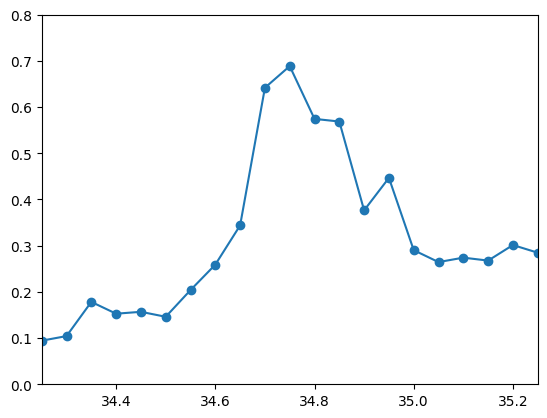

In [11]:
plt.plot(frequencies, taus, marker='o', label='Amplitude')
plt.xlim(34.25,35.25)
plt.ylim(0,0.8)
